In [1]:
%load_ext autoreload
%autoreload 2

# Load the BPMN Dataset

In [2]:
from mcp4cm.bpmn.dataloading.dataloading import BPMNModelCollection
from mcp4cm.bpmn.dataloading.bpmn_dataset import BPMNDataset
from mcp4cm.dataloading import load_dataset
from mcp4cm.base import DatasetType

Defining file path for saving dataset and loading it later on.

In [3]:
bpmn_dataset = load_dataset(path='data/bpmnmodelset', dataset_type=DatasetType.BPMNMODELSET, bpmn_model_collection=BPMNModelCollection.SAP_SAM)

Loading SAP SAM Dataset @ data/bpmnmodelset\sap_sam_2022/models:   1%|          | 1/103 [00:10<17:28, 10.28s/it]


In [4]:
from mcp4cm.bpmn.data_extraction import extract_names_from_models, calculate_model_hashes

use_types = False

if use_types:
    key = 'names_with_types'
    file_path = 'data/bpmnmodelset/processed/culled_with_typed_names.csv'
    empty_name = 'unknown type: empty name'
else:
    key = 'names'
    file_path = 'data/bpmnmodelset/processed/culled_with_names.csv'
    empty_name = 'empty name'


extract_names_from_models(bpmn_dataset, use_types=use_types, include_texts=True, include_documentation=True)


In [5]:
calculate_model_hashes(bpmn_dataset, key=key)

In [6]:

from bpmn.filter_functions import filter_empty_models, filter_models_by_min_element_count, \
    filter_models_by_max_element_count, filter_models_by_element_count, filter_models_by_empty_name_percentage, \
    filter_models_by_dummy_words, filter_models_by_median_name_length
from mcp4cm.dataloading import Dataset

print(bpmn_dataset)
Dataset.apply_filters(
    dataset=bpmn_dataset,
    filters=[
        filter_empty_models,
        filter_models_by_min_element_count,
        filter_models_by_max_element_count,
        filter_models_by_element_count,
        filter_models_by_empty_name_percentage,
        #filter_models_by_dummy_words
        filter_models_by_median_name_length,
    ],
)

print(bpmn_dataset)

Dataset(name=sapsam_2022_bpmn2, models=12033)
Filtered out models where every element is unnamed: 328
Filtered out models with element counts smaller than 5: 41
Filtered out models with element counts greater than 200: 126
Filtered out models with element counts outside of 5 and 200: 0
Filtered out models with a empty name percentage higher than 0.35: 0
Filtered out models with a median name length smaller than 4: 367
Dataset(name=sapsam_2022_bpmn2, models=11171)


In [7]:
from mcp4cm.language_detection import extract_dataset_languages, get_models_by_language

extract_dataset_languages(bpmn_dataset, text_key=key, empty_name=empty_name, override=True)


Language Extraction Progress:   0%|          | 0/11171 [00:00<?, ?it/s]

In [8]:
from mcp4cm.language_detection import filter_models_by_language
german_dataset = filter_models_by_language(bpmn_dataset, 'de', key=key, empty_name=empty_name)



In [9]:
#BPMNDataset.to_files(bpmn_dataset, output_directory='data/export/sam_german', include_svg=False);

In [10]:
#BPMNDataset.to_csv(bpmn_dataset, fp='data/bpmnmodelset/processed/german.csv')

creating tfidf for names
Generating Connectivity Graph
Connectivity Graph Done
Calculating connected Components
Calculating connected Components Done
Number of components: 1781
Finding unique files:
Creating Duplicate Groups

=== Dataset Statistics ===
Total files processed: 2918
Total unique files: 1744
Total duplicate files: 1174
Number of duplicate groups: 37


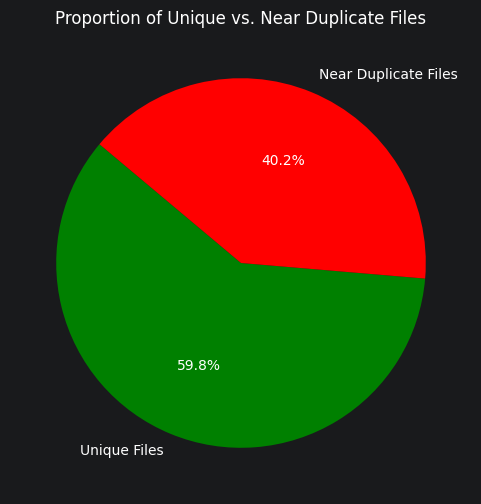

(Dataset(name=sapsam_2022_bpmn2_unique, models=1744),
 Dataset(name=sapsam_2022_bpmn2_duplicates, models=1174))

In [11]:
from mcp4cm.duplicate_detection import tfidf_near_duplicate_detector

tfidf_near_duplicate_detector(german_dataset, key, threshold=0.95, inplace=False, plt_fig=True, print_results=True)